# Use this notebook to actually train an SAE on the 2D data in figure 1A-C, to produce fig 1D, for example.

In [4]:
import numpy as np
import jax.numpy as jnp
import jax.nn as jnn
import matplotlib.pyplot as plt
import optax
from jax import jit, random, grad, value_and_grad

import math
import scipy


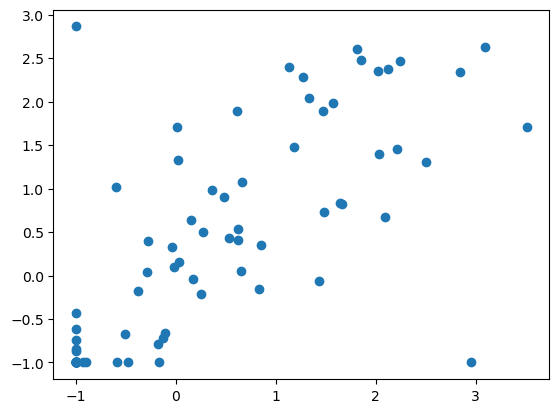

In [5]:
x = np.load('x_example_fig_1_c.npy')
plt.scatter(x[0,:], x[1,:])

In [8]:
N = 2
bias = 1
act_reg = 3
lamb = 0.001
D = x.shape[1]
random_seed = 4314

@jit
def stick_a_bias_on(g):
    g_bias = jnp.vstack([g, jnp.ones(g.shape[1])[None,:]])
    return g_bias

if bias:
    @jit
    def generate_R(g, outputs):
        mat0 = jnp.matmul(g, g.T)
        mat1 = jnp.matmul(g, outputs.T)
        mat2 = jnp.matmul(jnp.linalg.inv(mat0 + 0.01*jnp.eye(N+1)), mat1)
        return mat2

else:
    @jit
    def generate_R(g, outputs):
        mat0 = jnp.matmul(g, g.T)
        mat1 = jnp.matmul(g, outputs.T)
        mat2 = jnp.matmul(jnp.linalg.inv(mat0 + 0.01*jnp.eye(N)), mat1)
        return mat2
        
@jit
def loss_fit(g, R, outputs):
    preds = R.T@g
    return jnp.linalg.norm(outputs - preds)**2

if bias:
    @jit
    def loss_R(R):
        return jnp.sum(jnp.power(R[:N], 2))
else:
    @jit
    def loss_R(R):
        return jnp.sum(jnp.power(R, 2))
        
if act_reg == 2:
    @jit
    def loss_act(g):
        return jnp.sum(jnp.power(g, 2))
elif act_reg == 1:
    @jit
    def loss_act(g):
        return jnp.sum(jnp.abs(g))
elif act_reg == 3:
    @jit
    def loss_act(g):
        return np.sum(g.T@g)

@jit
def loss_pos(g):
    g_neg = (g - jnp.abs(g))/2
    L_pos = -jnp.sum(g_neg)
    return L_pos    

# Loss function parameters
mu_fit = 1
mu_G = lamb
mu_R = lamb
positivise = 1
if positivise:
    mu_pos = 0
else:
    mu_pos = 10000

@jit
def loss(params, outputs):
    if positivise:
        g_here = params['G'] - np.min(params['G'])
    else:
        g_here = params['G']
        
    if bias:
        g_use = stick_a_bias_on(g_here)
    else:
        g_use = g_here
        
    R = generate_R(g_use, outputs)

    return mu_fit*loss_fit(g_use, R, outputs) + mu_G*loss_act(g_here) + mu_R*loss_R(R) + mu_pos*loss_pos(g_here)
    
@jit
def update(params, outputs, opt_state):
    """ Compute the gradient for a batch and update the parameters """
    value, grads = value_and_grad(loss)(params, outputs)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, value

def measure_loss(params, outputs):
    if positivise:
        g_here = params['G'] - np.min(params['G'])
    else:
        g_here = params['G']
        
    if bias:
        g_use = stick_a_bias_on(g_here)
    else:
        g_use = g_here
        
    R = generate_R(g_use, outputs)

    l_fit = mu_fit*loss_fit(g_use, R, outputs)
    l_act = mu_G*loss_act(g_here)
    l_red = mu_R*loss_R(R)

    if positivise:
        l_tot = mu_fit*l_fit + mu_G*l_act + mu_R*l_red
        print(f'Loss: {l_tot:.5f}, fit: {l_fit:.5f}, act: {l_act:.5f}, red: {l_red:.5f}')
    else:
        l_pos = loss_pos(g_here)
        l_tot = mu_fit*l_fit + mu_G*l_act + mu_R*l_red + mu_pos*l_pos
        print(f'Loss: {l_tot:.5f}, fit: {l_fit:.5f}, act: {l_act:.5f}, red: {l_red:.5f}, pos: {l_pos:.5f}')
        
# Simulation parameters

re_init = 1
learning_rate = 1e-5

if re_init:
    key = random.PRNGKey(random_seed)
    G = random.normal(key, (N, D))*0.001
    optimizer = optax.adam(learning_rate)
    # Obtain the `opt_state` that contains statistics for the optimizer.
    params = {'G': G}
    opt_state = optimizer.init(params)
print(loss(params, x))
min_loss = np.inf

305.94135


In [11]:
# Only built for 2D x!!!
def measure_cross_dependence(g, x):
    cross_dependence = np.zeros(g.shape[0])
    x_dm = x - np.mean(x, axis = 1)[:,None]
    
    for g_dim in range(g.shape[0]):
        dependencies = np.zeros([2])
        g_dm = g[g_dim,:] - np.mean(g[g_dim,:])
        
        for x_dim in range(2):
            # First regress out the other x
            g_dm_regress_out = g_dm - (g_dm@x_dm[x_dim,:])*x_dm[x_dim,:]/np.linalg.norm(x_dm[x_dim,:])**2

            # Then measure projected variance on remaining
            dependencies[x_dim] = np.abs(g_dm_regress_out@x_dm[1-x_dim,:]/np.linalg.norm(x_dm[1-x_dim,:]))
            
        # Normalise by total var and take min
        cross_dependence[g_dim] = np.min(dependencies/np.linalg.norm(g_dm))

    return cross_dependence

measure_cross_dependence(params['G'], x) 

array([0.01542292, 0.37483433])

In [12]:
# Optimisation, run and re-run until it stops hitting new records
T = 150000
print_iter = 10000
thetas = np.arange(-0.95, 0.95, 0.15)


modularity_index = np.zeros(thetas.size)

for theta_ind, theta in enumerate(thetas):
    best_loss_this_theta = np.inf

    for repeat in range(3):
        print(f'Theta: {theta}, Repeat: {repeat}')
        
        # Reinitialise Optimiser
        random_seed = np.random.choice(10000)
        key = random.PRNGKey(random_seed)
        G = random.normal(key, (N, D))*0.01
        optimizer = optax.adam(learning_rate)
        params = {'G': G}
        opt_state = optimizer.init(params)
        min_loss_this_repeat = np.inf
    
        # Setup data
        U = np.array([[1, np.sin(theta)], [0, np.cos(theta)]]) 
        x_here = U@x
            
        for t in range(T):
            params, opt_state, loss = update(params, x_here, opt_state)
        
            if t % print_iter == 0:
                measure_loss(params, x_here)
                min_this_step = 0
        
            if loss < min_loss_this_repeat:
                params_best = params
                min_loss_this_repeat = loss
                if min_this_step == 0:
                    print(f'New min! {loss}')#, Theo: {act_loss_use + lamb*weight_loss_use:.5f}')
                    min_this_step = 1

        modularity_index[theta_ind] = np.mean(measure_cross_dependence(params_best['G'], x))
        print(modularity_index[theta_ind])

        if min_loss_this_repeat < best_loss_this_theta:
            best_params_this_theta = params_best
            best_loss_this_theta = min_loss_this_repeat

    
    modularity_index[theta_ind] = np.mean(measure_cross_dependence(params_best['G'], x))
    print(modularity_index[theta_ind])
        
    print(f'Theta: {theta}, Alignment: {modularity_index[theta_ind]}')

Theta: -0.95, Repeat: 0
Loss: 106.93523, fit: 106.93517, act: 0.01313, red: 0.04597
New min! 107.00908660888672
Loss: 1.75674, fit: 1.75546, act: 0.23533, red: 1.03893
New min! 3.0302822589874268
Loss: 0.27143, fit: 0.27042, act: 0.58544, red: 0.42504
New min! 1.2809240818023682
Loss: 0.21865, fit: 0.21761, act: 0.67093, red: 0.37305
New min! 1.2614690065383911
Loss: 0.19552, fit: 0.19449, act: 0.66137, red: 0.37457
New min! 1.2303317785263062
Loss: 0.19519, fit: 0.19416, act: 0.66118, red: 0.37509
New min! 1.2302619218826294
Loss: 0.19517, fit: 0.19414, act: 0.66115, red: 0.37508
Loss: 0.19524, fit: 0.19421, act: 0.66116, red: 0.37508
Loss: 0.19515, fit: 0.19412, act: 0.66114, red: 0.37509
New min! 1.2302614450454712
Loss: 0.19528, fit: 0.19424, act: 0.66111, red: 0.37507
Loss: 0.19524, fit: 0.19420, act: 0.66113, red: 0.37507
Loss: 0.19511, fit: 0.19408, act: 0.66119, red: 0.37511
Loss: 0.19527, fit: 0.19423, act: 0.66110, red: 0.37506
Loss: 0.19522, fit: 0.19418, act: 0.66111, red: 

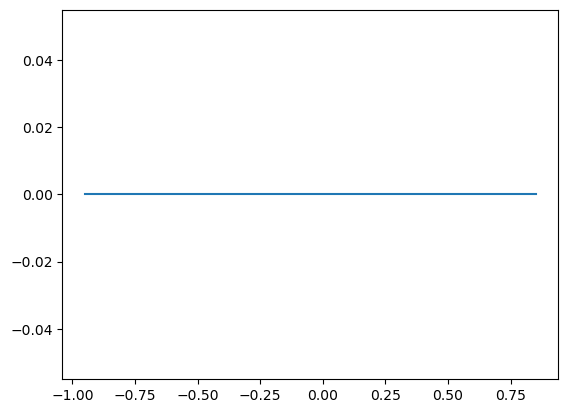

In [9]:
plt.subplot(1,2,1)
plt.plot(thetas, modularity_index)
plt.subplot(1,2,2)
plt.scatter(x[0,:], x[1,:], c = best_params_this_theta['G'][0,:], s = 100)

In [177]:
# Save it here for later pretty plotting in Clean_Plot_Maker
#np.save('modularity_index_b.npy', modularity_index)